In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [555]:
import random
# random.seed(42)

bin_ops = "+-*%/"

def make_expr(a, b, bin_op):
    result = 0
    if bin_op == "+": result = a + b
    elif bin_op == "-": result = a - b
    elif bin_op == "*": result = a * b
    elif bin_op == "%": result = a % b # a mod b 
    elif bin_op == "/": result = a // b
    expr = f"{a}{bin_op}{b}={result}?"
    expr = expr.replace("+-", "-")
    expr = expr.replace("--", "+")
    return expr

def generate_sample():
    a, b = random.randint(1, 50), random.randint(1, 50)
    bin_op = bin_ops[random.randint(0, len(bin_ops)-1)]
    return make_expr(a, b, bin_op)

print(generate_sample())

21*47=987?


In [556]:
bag_of_word = "_?0123456789+-*%/="
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["-"]]

PAD = bag_of_word.index("_")
EOS = bag_of_word.index("?")

In [557]:
ds = 100000
chunks = [generate_sample() for _ in range(ds)]

In [558]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [7, 2, 15, 5, 9, 17, 3, 5, 1]
String: 50%37=13?


In [559]:
max_length = max(list(map(len, chunks)))
max_length

11

In [593]:
import tqdm

device = "mps"

# emb_size = 100

# optimizer = optim.SGD(parameters, lr=1e-3)
small_batch = 1024
def padding(tokens, length):
    return F.pad(torch.tensor(tokens, dtype=torch.long), (0, length-len(tokens)), "constant", PAD)

token_chunks = torch.stack([padding(tokenize(chunk), max_length) for chunk in chunks], dim=0).to(device)

In [594]:
mask = torch.zeros((token_chunks.shape[0], max_length-1), device=device)
for i, chunk in enumerate(chunks):
    mask[i, chunk.index("="):chunk.index("?")]=1

In [595]:
def dataload():
    chosen = torch.randint(0, len(token_chunks), (small_batch,), device=device)
    inds = token_chunks[chosen]
    return inds, mask[chosen]

In [596]:
import math

emb_size = 256
hidden_size = 256

class TinyRNNLayer(nn.Module):
    def __init__(self, emb_size, hidden_size, total_tokens):
        super().__init__()
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.total_tokens = total_tokens
        
        self.model = nn.Sequential(
            nn.Linear(emb_size+hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, emb_size+hidden_size)
        )
        self.proj = nn.Linear(emb_size, emb_size)
        self.act = nn.ReLU()
        self.register_buffer("mask", torch.ones(max_length, max_length).tril())

    def forward(self, x, hidden=None):
        B, T, C = x.shape
        if hidden == None:
            hidden = self.init_hidden(B)
        outs = []
        for t in range(T):
            agg = torch.cat([x[:,t,:], hidden], dim=-1)
            out, hidden = torch.split(self.model(agg), [self.emb_size, self.hidden_size], dim=-1)
            hidden = torch.tanh(hidden)
            outs.append(out)
        outs = torch.stack(outs, dim=1)

        if not self.training:
            mask = torch.ones((x.shape[1], x.shape[1]), device=device).tril()
        else:
            mask = self.mask

        cos = (outs @ torch.transpose(outs, 1, 2))
        cos.masked_fill_(mask!=1, float("-inf"))
        attention_weight = F.softmax(cos / math.sqrt(emb_size), dim=-1)
        outs = attention_weight @ outs
        outs = self.act(self.proj(self.act(outs)))

        return outs, hidden

    def init_hidden(self, n):
        return nn.init.kaiming_uniform_(torch.empty(n, self.hidden_size, device=device))

class TinyRNN(nn.Module):
    def __init__(self, layers, emb_size, hidden_size, total_tokens):
        super().__init__()
        self.n_layers = layers
        self.layers = nn.ModuleList(
            [TinyRNNLayer(emb_size, hidden_size, total_tokens) for _ in range(layers)]
        )
        self.emb_table = nn.Embedding(total_tokens, emb_size)
        self.act = nn.ReLU()
        self.proj = nn.Linear(emb_size, total_tokens)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.emb_table(x)
        for layer in self.layers:
            out, hi = layer(self.dropout(x))
            x = x + out
        proj = self.proj(self.act(x)) # [B, T, C]
        return proj

def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.kaiming_uniform_(m.weight.data)

model = TinyRNN(3, emb_size, hidden_size, total_tokens).to(device)
model.apply(initialize_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

In [597]:
losses = []

In [598]:
train_model = model
train_model.train()
for epoch in tqdm.trange(10000):
    inds, loss_mask = dataload()
    logits = train_model(inds)
    logits_trunc  = logits[:, :max_length-1, :]    # [B, T-1, V]
    targets_trunc = inds[:, 1:]           # [B, T-1]

    entropy_loss = F.cross_entropy(
        logits_trunc.contiguous().view(-1, total_tokens),
        targets_trunc.contiguous().view(-1),
        ignore_index=PAD,
        reduction="none",
    )
    loss_mask = loss_mask.contiguous().view(-1)
    loss = (entropy_loss * loss_mask).sum() / loss_mask.sum()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(train_model.parameters(), max_norm=1.0)
    optimizer.step()

    if epoch % 100 == 0:
        pred = torch.argmax(logits[0], dim=1).tolist()
        x = inds[0].detach().cpu().tolist()
        formula = stringfy(x)
        pred_formula = stringfy(pred)
        result_loc = formula.index('=')
        try:
            pred_result = pred_formula[result_loc:][:pred_formula[result_loc:].index("?")]
        except: pred_result = ""
        print(f"{formula} -> {pred_result}")
        print("Entropy Error:", loss.item())
    losses.append(loss.item())

  0%|          | 3/10000 [00:00<29:17,  5.69it/s]  

32%24=8?___ -> 
Entropy Error: 3.263237237930298


  1%|          | 103/10000 [00:07<11:46, 14.02it/s]

50/34=1?___ -> 0
Entropy Error: 1.2399299144744873


  2%|▏         | 203/10000 [00:15<19:24,  8.42it/s]

...

 98%|█████████▊| 9803/10000 [13:08<00:14, 13.57it/s]

2-1=1?_____ -> 1
Entropy Error: 0.18588565289974213


 99%|█████████▉| 9903/10000 [13:16<00:07, 13.69it/s]

22%36=22?__ -> 22
Entropy Error: 0.20192226767539978


100%|██████████| 10000/10000 [13:23<00:00, 12.45it/s]


Text(0.5, 0, 'epoch')

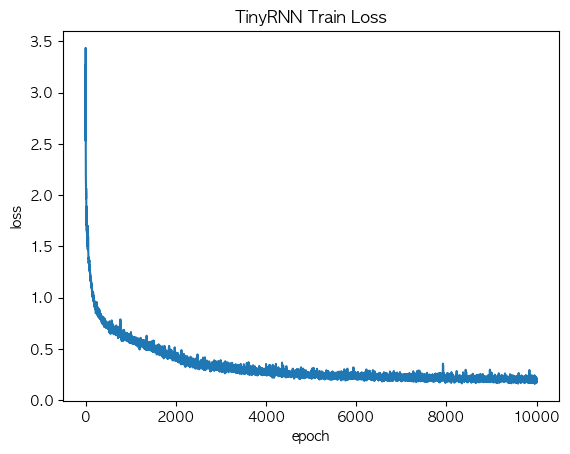

In [599]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("TinyRNN Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [610]:
inds, loss_mask = dataload()
x = inds[0].unsqueeze(0)

model.eval()
emb = model.emb_table(x)
x = model.emb_table(x)
    # layer = model.layers[0]
attention_weights = []
for layer in model.layers:
    B, T, C = x.shape
    hidden = layer.init_hidden(B)
    outs = []
    for t in range(T):
        agg = torch.cat([x[:,t,:], hidden], dim=-1)
        out, hidden = torch.split(layer.model(agg), [layer.emb_size, layer.hidden_size], dim=-1)
        hidden = torch.tanh(hidden)
        outs.append(out)
    outs = torch.stack(outs, dim=1)

    if not layer.training:
        mask = torch.ones((x.shape[1], x.shape[1]), device=device).tril()
    else:
        mask = layer.mask

    cos = (outs @ torch.transpose(outs, 1, 2))
    cos.masked_fill_(mask!=1, float("-inf"))
    attention_weight = F.softmax(cos / math.sqrt(emb_size), dim=-1)
    outs = attention_weight @ outs
    outs = layer.act(layer.proj(layer.act(outs)))
    attention_weights.append(attention_weight.cpu().detach().permute(1, 2, 0).numpy())
    x += outs

/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


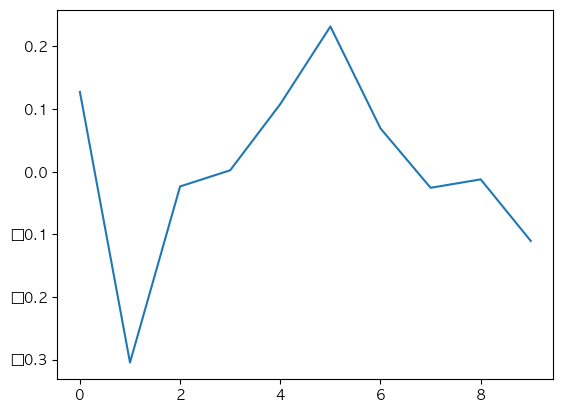

In [584]:
tokens = torch.tensor([2, 3, 4, 5, 6, 7, 8, 9, 10, 11], device=device)
# self.emb_table(tokens).shape
freq = torch.fft.fft(model.emb_table(tokens).to("cpu"), n=10)
plt.plot(freq.real.mean(-1).cpu().detach())

In [585]:
tokenize("0123456789")

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [601]:
formula = stringfy(inds[0].detach().cpu().tolist())
formula

'41/23=1?___'

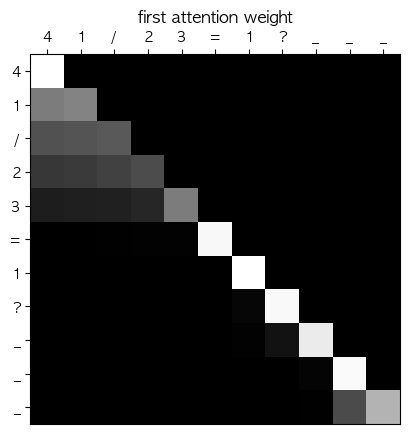

In [611]:
plt.title("first attention weight")
plt.imshow(attention_weights[0], cmap="gray", vmin=0, vmax=1)
labels = [ch for ch in formula]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.gca().xaxis.tick_top() 
plt.gca().xaxis.set_label_position("top")

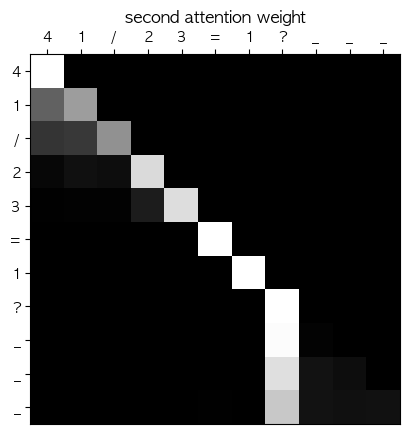

In [612]:
plt.title("second attention weight")
plt.imshow(attention_weights[1], cmap="gray", vmin=0, vmax=1)
labels = [ch for ch in formula]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.gca().xaxis.tick_top() 
plt.gca().xaxis.set_label_position("top")

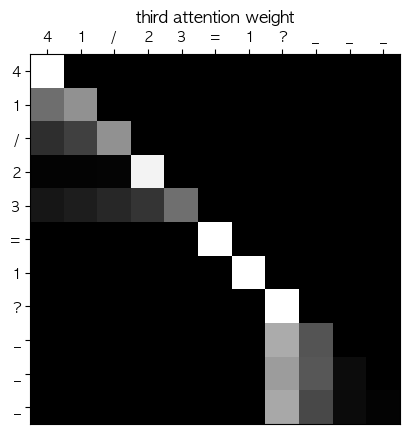

In [613]:
plt.title("third attention weight")
plt.imshow(attention_weights[2], cmap="gray", vmin=0, vmax=1)
labels = [ch for ch in formula]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.gca().xaxis.tick_top() 
plt.gca().xaxis.set_label_position("top")

In [450]:
attention_weight[0][4]

tensor([1.1605e-07, 3.8900e-10, 9.1248e-10, 9.5578e-09, 1.0000e+00, 3.2910e-10,
        3.2910e-10, 3.2910e-10, 3.2910e-10, 3.2910e-10, 3.2910e-10],
       device='mps:0', grad_fn=<SelectBackward0>)

In [538]:
def generate(x, model, max_length):
    indexs = torch.tensor(tokenize(x.replace(" ", "_")), dtype=torch.long, device=device)
    model.eval()
    with torch.no_grad():
        for i in range(max_length):
            logits = model(indexs[None, :])
            last_logits = logits[0, -1]
            next_tok = torch.multinomial(F.softmax(last_logits, dim=0), 1)
            next_tok = torch.argmax(last_logits, keepdim=True)
            if next_tok.item() == EOS:
                break
            indexs = torch.cat([indexs, next_tok], dim=0)
    model.train()
    return stringfy(indexs.tolist())

In [605]:
generate("10+11=", model, max_length=50)

'10+11=21'

In [606]:
generate("10*21=", model, max_length=50)

'10*21=210'

In [607]:
generate("30%21=", model, max_length=50)

'30%21=9'

In [608]:
generate("100-92=", model, max_length=50)

'100-92=0'

In [609]:
generate("100*30=", model, max_length=50)

'100*30=300'

(-0.5, 49.5, 49.5, -0.5)

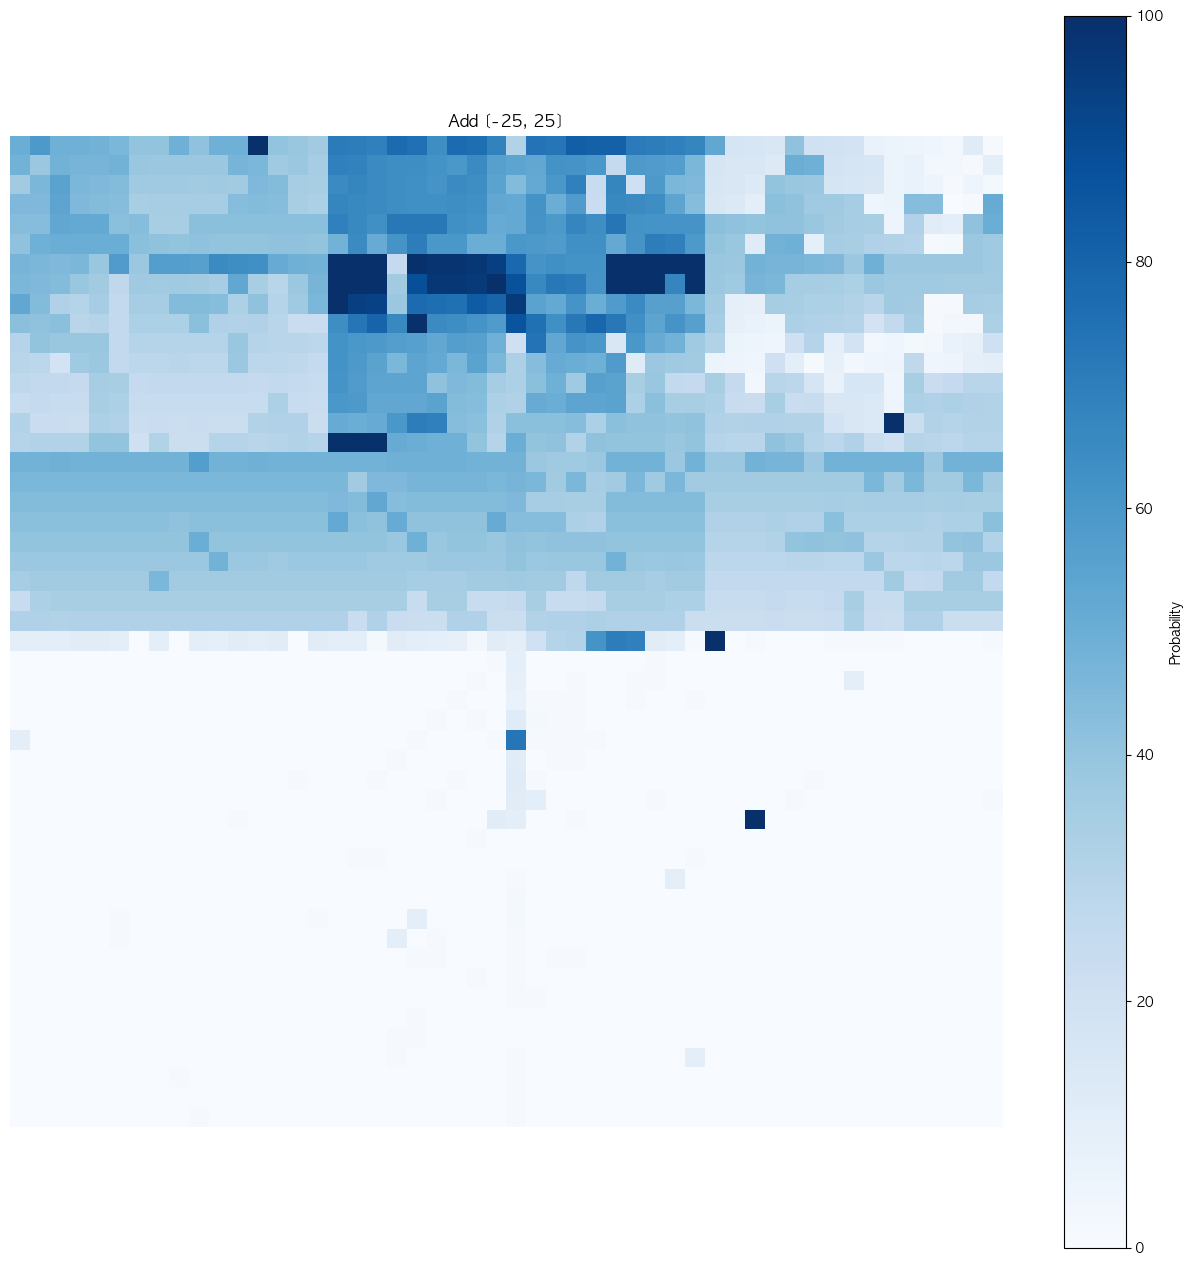

In [382]:
image = torch.ones((50, 50))*100

model.eval()
for a in range(50):
    for b in range(50):
        aa, bb = a - 25, b - 25
        expr = make_expr(aa, bb, "+")
        generation = generate(expr[:expr.index("=")+1], model, max_length=10)
        pred = generation.replace("=", "").replace("?", "")[expr.index("="):]
        try:
            pred = int(pred)
            image[a, b] = abs(aa+bb-pred)
        except ValueError: print(aa, bb, pred)
model.train()

plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(image.clip(0, 100), cmap="Blues")
plt.colorbar(label="Probability")
plt.title("Add [-25, 25]")
plt.axis("off")
# for i in range(201):
#     for j in range(201):
#         plt.text(j, i, ha="center", va="center", color="gray")